# Общий CV-пайплайн квартиры

Ноутбук загружает готовые классификаторы стен, пола и потолка. SegFormer выполняется один раз для каждого изображения, после чего DINOv2 и соответствующая голова классификации определяют покрытие каждой найденной поверхности. Результат сохраняется в одном JSON без расчёта стоимости.


In [1]:
from pathlib import Path
import base64
import json

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from scipy import ndimage
from transformers import AutoImageProcessor, AutoModel, SegformerForSemanticSegmentation
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PROJECT = Path('/Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV')
OUTPUT_DIR = PROJECT / 'outputs/combined_inference'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINTS = {
    'walls': PROJECT / 'outputs/wall_training/current/best.pt',
    'floors': PROJECT / 'outputs/floor_training/current/best.pt',
    'ceilings': PROJECT / 'outputs/ceiling_training/current/best.pt',
}
for surface, checkpoint_path in CHECKPOINTS.items():
    assert checkpoint_path.is_file(), f'Не найден чекпоинт {surface}: {checkpoint_path}'

SEGFORMER_NAME = 'nvidia/segformer-b0-finetuned-ade-512-512'
DINO_NAME = 'facebook/dinov2-small'
GLOBAL_DINO_SIZE = 448
LOCAL_DINO_SIZE = 224
LOCAL_VIEWS = 9
MAX_VIEWS = {'walls': 3, 'floors': 3, 'ceilings': 3}
MIN_COMPONENT_AREA = 0.03
MIN_CONFIDENCE = {'walls': 0.45, 'floors': 0.40, 'ceilings': 0.40}
MATERIAL_OUTPUT_THRESHOLD = 0.40
ROOM_STATE_THRESHOLD = 0.60
STRONG_DISTINCT_CEILING_THRESHOLD = 0.75
SEGMENTATION_CONFIDENCE = {'wall': 0.50, 'floor': 0.40, 'rug': 0.40, 'ceiling': 0.40}

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)
print('Output:', OUTPUT_DIR)


Device: mps
Output: /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/outputs/combined_inference


## 1. Загрузка трёх классификаторов и общих моделей

SegFormer и DINOv2 загружаются по одному разу. Отдельными остаются только небольшие обученные головы классификации.


In [2]:
class SurfaceClassifier(torch.nn.Module):
    def __init__(self, feature_dim, num_classes):
        super().__init__()
        self.attention = torch.nn.Sequential(
            torch.nn.Linear(feature_dim, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 1),
        )
        fused_dim = feature_dim * 3
        self.shared = torch.nn.Sequential(
            torch.nn.LayerNorm(fused_dim),
            torch.nn.Linear(fused_dim, 384),
            torch.nn.GELU(),
            torch.nn.Dropout(0.30),
        )
        self.class_head = torch.nn.Linear(384, num_classes)

    def fused_features(self, global_embedding, local_embeddings):
        attention_weights = self.attention(local_embeddings).squeeze(-1).softmax(1)
        attended = (local_embeddings * attention_weights.unsqueeze(-1)).sum(1)
        maximum = local_embeddings.max(1).values
        shared = self.shared(torch.cat([global_embedding, attended, maximum], dim=1))
        return shared, attention_weights

    def forward(self, global_embedding, local_embeddings):
        shared, attention_weights = self.fused_features(global_embedding, local_embeddings)
        return self.class_head(shared), attention_weights


class WallClassifier(SurfaceClassifier):
    def __init__(self, feature_dim, num_classes):
        super().__init__(feature_dim, num_classes)
        self.drywall_head = torch.nn.Linear(384, 2)

    def forward(self, global_embedding, local_embeddings):
        shared, attention_weights = self.fused_features(global_embedding, local_embeddings)
        return self.class_head(shared), self.drywall_head(shared), attention_weights


checkpoints = {
    surface: torch.load(path, map_location='cpu', weights_only=True)
    for surface, path in CHECKPOINTS.items()
}

classifiers = {}
for surface, checkpoint in checkpoints.items():
    assert checkpoint['local_views'] == LOCAL_VIEWS
    if surface == 'walls':
        model = WallClassifier(checkpoint['feature_size'], len(checkpoint['classes']))
    else:
        model = SurfaceClassifier(checkpoint['feature_size'], len(checkpoint['classes']))
    model.load_state_dict(checkpoint['state_dict'])
    classifiers[surface] = model.to(device).eval()

segmenter_processor = AutoImageProcessor.from_pretrained(SEGFORMER_NAME)
segmenter = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_NAME).to(device).eval()
dino_processor = AutoImageProcessor.from_pretrained(DINO_NAME)
dino = AutoModel.from_pretrained(DINO_NAME).to(device).eval()
for parameter in dino.parameters():
    parameter.requires_grad = False

label_to_id = {label: int(class_id) for class_id, label in segmenter.config.id2label.items()}
for required_label in ['wall', 'floor', 'rug', 'ceiling']:
    assert required_label in label_to_id, f'В SegFormer отсутствует класс {required_label}'

for surface, checkpoint in checkpoints.items():
    print(surface, checkpoint['classes'])


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

walls ['bare_unfinished_wall', 'exposed_drywall', 'rigid_decorative_cladding', 'tile', 'unfinished_plaster_or_putty', 'wallpaper']
floors ['bare_unfinished_floor', 'carpet', 'tile_or_stone', 'vinyl_or_linoleum', 'wood_flooring']
ceilings ['bare_unfinished_ceiling', 'drywall_ceiling', 'glued_light_ceiling_finish', 'modular_or_panel_ceiling', 'stretch_ceiling']


## 2. Однократная сегментация стен, пола и потолка

Для пола сохраняется прежнее правило: видимый настоящий пол имеет приоритет над переносным ковром; маска `rug` используется только тогда, когда другого пола почти не видно.


In [3]:
def encode_small_mask(mask, max_side=160):
    image = Image.fromarray((mask.astype(np.uint8) * 255), mode='L')
    scale = min(1.0, max_side / max(image.size))
    size = (max(1, round(image.width * scale)), max(1, round(image.height * scale)))
    image = image.resize(size, Image.Resampling.NEAREST)
    binary = np.asarray(image) >= 128
    packed = np.packbits(binary.reshape(-1))
    return base64.b64encode(packed.tobytes()).decode('ascii'), binary.shape[0], binary.shape[1]


def decode_mask(mask_data, height, width, output_size):
    packed = np.frombuffer(base64.b64decode(mask_data), dtype=np.uint8)
    mask = np.unpackbits(packed, count=int(height) * int(width)).reshape(int(height), int(width))
    return Image.fromarray((mask * 255).astype(np.uint8), mode='L').resize(
        output_size, Image.Resampling.NEAREST
    )


def clean_mask(mask):
    return 1 - F.max_pool2d(
        F.pad(1 - mask[None, None], (2, 2, 2, 2), value=1),
        5,
        stride=1,
    )[0, 0]


def select_local_boxes(component, offset_x, offset_y, scale_x, scale_y):
    height, width = component.shape
    size = min(max(48, int(min(width, height) * 0.30)), width, height)
    integral = np.pad(component.astype(np.int32).cumsum(0).cumsum(1), ((1, 0), (1, 0)))

    def coverage(x0, y0, x1, y1):
        value = integral[y1, x1] - integral[y0, x1] - integral[y1, x0] + integral[y0, x0]
        return float(value / ((x1 - x0) * (y1 - y0)))

    stride = max(12, size // 4)
    xs = list(range(0, width - size + 1, stride))
    ys = list(range(0, height - size + 1, stride))
    if xs and xs[-1] != width - size:
        xs.append(width - size)
    if ys and ys[-1] != height - size:
        ys.append(height - size)

    candidates = []
    for y0 in ys:
        for x0 in xs:
            value = coverage(x0, y0, x0 + size, y0 + size)
            if value >= 0.72:
                candidates.append({
                    'box': (x0, y0, x0 + size, y0 + size),
                    'coverage': value,
                    'cx': (x0 + size / 2) / width,
                    'cy': (y0 + size / 2) / height,
                })
    if not candidates:
        candidates = [{
            'box': ((width-size)//2, (height-size)//2, (width+size)//2, (height+size)//2),
            'coverage': 0.0,
            'cx': 0.5,
            'cy': 0.5,
        }]

    selected, used = [], set()
    for target_y in (0.17, 0.50, 0.83):
        for target_x in (0.17, 0.50, 0.83):
            ranked = sorted(
                enumerate(candidates),
                key=lambda item: (item[1]['cx']-target_x)**2 + (item[1]['cy']-target_y)**2 - 0.20*item[1]['coverage'],
            )
            choice = next(((index, item) for index, item in ranked if index not in used), ranked[0])
            used.add(choice[0])
            selected.append(choice[1]['box'])

    return [
        {
            'x0': round((offset_x+x0)*scale_x),
            'y0': round((offset_y+y0)*scale_y),
            'x1': round((offset_x+x1)*scale_x),
            'y1': round((offset_y+y1)*scale_y),
        }
        for x0, y0, x1, y1 in selected
    ]


def extract_components(mask, original_size, work_size, max_views, mask_source=None):
    binary = mask.detach().cpu().numpy() >= 0.5
    labels, _ = ndimage.label(binary)
    objects = ndimage.find_objects(labels)
    image_area = work_size[0] * work_size[1]
    candidates = []

    for component_id, slices in enumerate(objects, start=1):
        if slices is None:
            continue
        ys, xs = slices
        component = labels[ys, xs] == component_id
        area = int(component.sum())
        if area < image_area * MIN_COMPONENT_AREA:
            continue
        y0, y1 = ys.start, ys.stop
        x0, x1 = xs.start, xs.stop
        if x1 - x0 < 64 or y1 - y0 < 64:
            continue
        box_coverage = area / ((x1-x0)*(y1-y0))
        candidates.append((area, box_coverage, (x0,y0,x1,y1), component))

    candidates.sort(key=lambda item: item[0], reverse=True)
    scale_x = original_size[0] / work_size[0]
    scale_y = original_size[1] / work_size[1]
    views = []
    for area, box_coverage, (x0,y0,x1,y1), component in candidates[:max_views]:
        mask_data, mask_h, mask_w = encode_small_mask(component)
        view = {
            'x0': round(x0*scale_x), 'y0': round(y0*scale_y),
            'x1': round(x1*scale_x), 'y1': round(y1*scale_y),
            'segmentation_image_fraction': float(area/image_area),
            'segmentation_box_coverage': float(box_coverage),
            'mask_data': mask_data, 'mask_h': mask_h, 'mask_w': mask_w,
            'local_boxes': select_local_boxes(component, x0, y0, scale_x, scale_y),
        }
        if mask_source is not None:
            view['mask_source'] = mask_source
        views.append(view)
    return views


@torch.no_grad()
def segment_all_surfaces(image_path):
    with Image.open(image_path) as source:
        original = ImageOps.exif_transpose(source).convert('RGB')
    work = original.copy()
    work.thumbnail((1024, 1024), Image.Resampling.LANCZOS)

    inputs = segmenter_processor(images=work, return_tensors='pt').to(device)
    logits = segmenter(**inputs).logits
    probabilities = F.interpolate(
        logits, size=(work.height, work.width), mode='bilinear', align_corners=False
    ).softmax(1)
    predicted = probabilities.argmax(1)

    def surface_mask(label):
        class_id = label_to_id[label]
        mask = ((predicted == class_id) & (probabilities[:, class_id] >= SEGMENTATION_CONFIDENCE[label])).float()[0]
        return clean_mask(mask)

    wall_mask = surface_mask('wall')
    ceiling_mask = surface_mask('ceiling')
    floor_mask = surface_mask('floor')
    rug_mask = surface_mask('rug')

    floor_binary = floor_mask.detach().cpu().numpy() >= 0.5
    floor_labels, floor_count = ndimage.label(floor_binary)
    floor_areas = np.bincount(floor_labels.reshape(-1))[1:] if floor_count else np.array([])
    visible_floor = bool(len(floor_areas) and floor_areas.max() >= work.width*work.height*MIN_COMPONENT_AREA)
    selected_floor_mask = floor_mask if visible_floor else rug_mask
    floor_source = 'floor' if visible_floor else 'rug'

    surfaces = {
        'walls': extract_components(wall_mask, original.size, work.size, MAX_VIEWS['walls']),
        'floors': extract_components(selected_floor_mask, original.size, work.size, MAX_VIEWS['floors'], floor_source),
        'ceilings': extract_components(ceiling_mask, original.size, work.size, MAX_VIEWS['ceilings']),
    }
    return original, surfaces


## 3. Классификация найденных поверхностей

Все глобальные и локальные изображения одного исходного кадра проходят DINOv2 общими пакетами. В JSON не попадают служебные маски и attention-веса.


In [4]:
def render_surface_view(original, view):
    crop = original.crop((view['x0'], view['y0'], view['x1'], view['y1']))
    mask = decode_mask(view['mask_data'], view['mask_h'], view['mask_w'], crop.size)
    return Image.composite(crop, Image.new('RGB', crop.size, (128,128,128)), mask)


def render_local_views(original, view):
    return [
        original.crop((box['x0'], box['y0'], box['x1'], box['y1']))
        for box in view['local_boxes']
    ]


def wall_probabilities(class_logits, drywall_logits, classes):
    drywall_index = classes.index('exposed_drywall')
    class_log_probs = class_logits.log_softmax(1)
    drywall_log_probs = drywall_logits.log_softmax(1)
    combined = class_log_probs.clone()
    combined[:, drywall_index] += drywall_log_probs[:, 1]
    non_drywall = torch.ones(len(classes), dtype=torch.bool, device=combined.device)
    non_drywall[drywall_index] = False
    combined[:, non_drywall] += drywall_log_probs[:, 0, None]
    return combined.softmax(1)


@torch.no_grad()
def classify_surfaces(original, surface_views):
    items = [
        (surface, view_index, view)
        for surface, views in surface_views.items()
        for view_index, view in enumerate(views, start=1)
    ]
    results = {surface: [] for surface in ['walls','floors','ceilings']}
    if not items:
        return results

    global_images = [render_surface_view(original, view) for _,_,view in items]
    local_images = [image for _,_,view in items for image in render_local_views(original, view)]
    global_inputs = dino_processor(
        images=global_images, return_tensors='pt', do_resize=True,
        size={'height':GLOBAL_DINO_SIZE,'width':GLOBAL_DINO_SIZE}, do_center_crop=False,
    ).to(device)
    local_inputs = dino_processor(
        images=local_images, return_tensors='pt', do_resize=True,
        size={'height':LOCAL_DINO_SIZE,'width':LOCAL_DINO_SIZE}, do_center_crop=False,
    ).to(device)
    global_embeddings = dino(**global_inputs).last_hidden_state[:,0]
    local_embeddings = dino(**local_inputs).last_hidden_state[:,0].reshape(len(items),LOCAL_VIEWS,-1)

    for item_index, (surface, region_index, view) in enumerate(items):
        checkpoint = checkpoints[surface]
        classes = checkpoint['classes']
        global_embedding = global_embeddings[item_index:item_index+1]
        local_embedding = local_embeddings[item_index:item_index+1]
        extra = {}

        if surface == 'walls':
            class_logits, drywall_logits, _ = classifiers[surface](global_embedding, local_embedding)
            probability = wall_probabilities(class_logits, drywall_logits, classes)[0]
            extra['drywall_evidence'] = round(float(drywall_logits.softmax(1)[0,1].item()),3)
        else:
            class_logits, _ = classifiers[surface](global_embedding, local_embedding)
            probability = class_logits.softmax(1)[0]

        class_index = int(probability.argmax().item())
        confidence = float(probability[class_index].item())
        public_view = {
            key: value for key, value in view.items()
            if key not in {'mask_data','mask_h','mask_w','local_boxes'}
        }
        result = {
            'region_id': region_index,
            'bbox': {
                'x0': public_view.pop('x0'), 'y0': public_view.pop('y0'),
                'x1': public_view.pop('x1'), 'y1': public_view.pop('y1'),
            },
            **{key: round(float(value),4) if isinstance(value,float) else value for key,value in public_view.items()},
            'material': classes[class_index] if confidence >= MIN_CONFIDENCE[surface] else 'uncertain',
            'top_candidate': classes[class_index],
            'confidence': round(confidence,3),
            'probabilities': {
                name: round(float(value),3) for name,value in zip(classes,probability.detach().cpu())
            },
            **extra,
        }
        results[surface].append(result)
    return results


def analyze_image(image_path):
    image_path = Path(image_path)
    original, views = segment_all_surfaces(image_path)
    surfaces = classify_surfaces(original, views)
    missing = [surface for surface, predictions in surfaces.items() if not predictions]
    return {
        'image': image_path.name,
        'path': str(image_path.resolve()),
        'width': original.width,
        'height': original.height,
        'surfaces': surfaces,
        'warnings': [f'{surface}: surface_not_found' for surface in missing],
    }


## 4. Чистый JSON материалов комнаты

В итог попадают только три списка материалов и их confidence. Один класс добавляется один раз с максимальной уверенностью по всем областям и фотографиям. Если несколько материалов проходят порог 0.40, сохраняются все.

Для явно черновой комнаты действует проверка согласованности: уверенные `bare_unfinished_wall` и `bare_unfinished_floor` исправляют слабое или противоречивое распознавание потолка как гипсокартона. Сильный визуально отличимый потолок не перезаписывается.


In [5]:
def collect_material_scores(image_results):
    scores = {'walls': {}, 'floor': {}, 'ceiling': {}}
    surface_names = {'walls':'walls', 'floors':'floor', 'ceilings':'ceiling'}

    for image_result in image_results:
        for internal_surface, predictions in image_result['surfaces'].items():
            output_surface = surface_names[internal_surface]
            for prediction in predictions:
                # Несколько классов одной области сохраняются только тогда,
                # когда каждый из них сам проходит единый порог 0.40.
                for material, probability in prediction['probabilities'].items():
                    probability = float(probability)
                    if probability < MATERIAL_OUTPUT_THRESHOLD:
                        continue
                    scores[output_surface][material] = max(
                        scores[output_surface].get(material, 0.0),
                        probability,
                    )
    return scores


def apply_room_consistency(scores):
    wall_scores = scores['walls']
    floor_scores = scores['floor']
    ceiling_scores = scores['ceiling']
    bare_wall = wall_scores.get('bare_unfinished_wall', 0.0)
    bare_floor = floor_scores.get('bare_unfinished_floor', 0.0)
    strongest_finished_wall = max(
        (confidence for material,confidence in wall_scores.items() if material!='bare_unfinished_wall'),
        default=0.0,
    )

    unfinished_room = (
        bare_wall >= ROOM_STATE_THRESHOLD
        and bare_floor >= ROOM_STATE_THRESHOLD
        and bare_wall >= strongest_finished_wall
    )
    distinctive_ceiling = max(
        ceiling_scores.get('stretch_ceiling',0.0),
        ceiling_scores.get('glued_light_ceiling_finish',0.0),
        ceiling_scores.get('modular_or_panel_ceiling',0.0),
    )

    if unfinished_room and distinctive_ceiling < STRONG_DISTINCT_CEILING_THRESHOLD:
        scores['ceiling'] = {
            'bare_unfinished_ceiling': min(bare_wall,bare_floor)
        }
    return scores


def clean_material_json(image_results):
    scores = apply_room_consistency(collect_material_scores(image_results))
    result = {}
    for surface in ['walls','floor','ceiling']:
        materials = [
            {'material':material, 'confidence':round(float(confidence),3)}
            for material,confidence in scores[surface].items()
        ]
        materials.sort(key=lambda item:item['confidence'], reverse=True)
        result[surface] = materials
    return result


def analyze_room(image_paths):
    image_results = [analyze_image(Path(image_path)) for image_path in image_paths]
    return clean_material_json(image_results)


## 5. Запуск на тестовых фотографиях

Укажи нужные файлы в `IMAGE_PATHS`. В файл записывается только чистый JSON. Результат всегда перезаписывается в одном месте: `outputs/combined_inference/room_analysis.json`.


In [6]:
TEST_DIR = PROJECT / 'data/dataset/test'
extensions = {'.jpg','.jpeg','.png','.webp','.bmp','.tif','.tiff'}
IMAGE_PATHS = sorted(path for path in TEST_DIR.iterdir() if path.is_file() and path.suffix.lower() in extensions)[3:7]
assert IMAGE_PATHS, f'В {TEST_DIR} нет изображений'

detailed_results = [analyze_image(image_path) for image_path in IMAGE_PATHS]
room_result = clean_material_json(detailed_results)
output_path = OUTPUT_DIR / 'room_analysis.json'
output_path.write_text(json.dumps(room_result, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(room_result, ensure_ascii=False, indent=2))
print('JSON:', output_path)


{
  "walls": [
    {
      "material": "wallpaper",
      "confidence": 0.999
    },
    {
      "material": "bare_unfinished_wall",
      "confidence": 0.999
    },
    {
      "material": "rigid_decorative_cladding",
      "confidence": 0.967
    }
  ],
  "floor": [
    {
      "material": "carpet",
      "confidence": 0.942
    },
    {
      "material": "bare_unfinished_floor",
      "confidence": 0.938
    }
  ],
  "ceiling": [
    {
      "material": "stretch_ceiling",
      "confidence": 0.957
    },
    {
      "material": "glued_light_ceiling_finish",
      "confidence": 0.754
    },
    {
      "material": "drywall_ceiling",
      "confidence": 0.508
    }
  ]
}
JSON: /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/outputs/combined_inference/room_analysis.json


## 6. Визуальная проверка областей

Рамки показывают найденные поверхности и итоговый материал. Эта ячейка использует внутренние подробные результаты, которые в JSON не сохраняются и не запускает модели повторно.


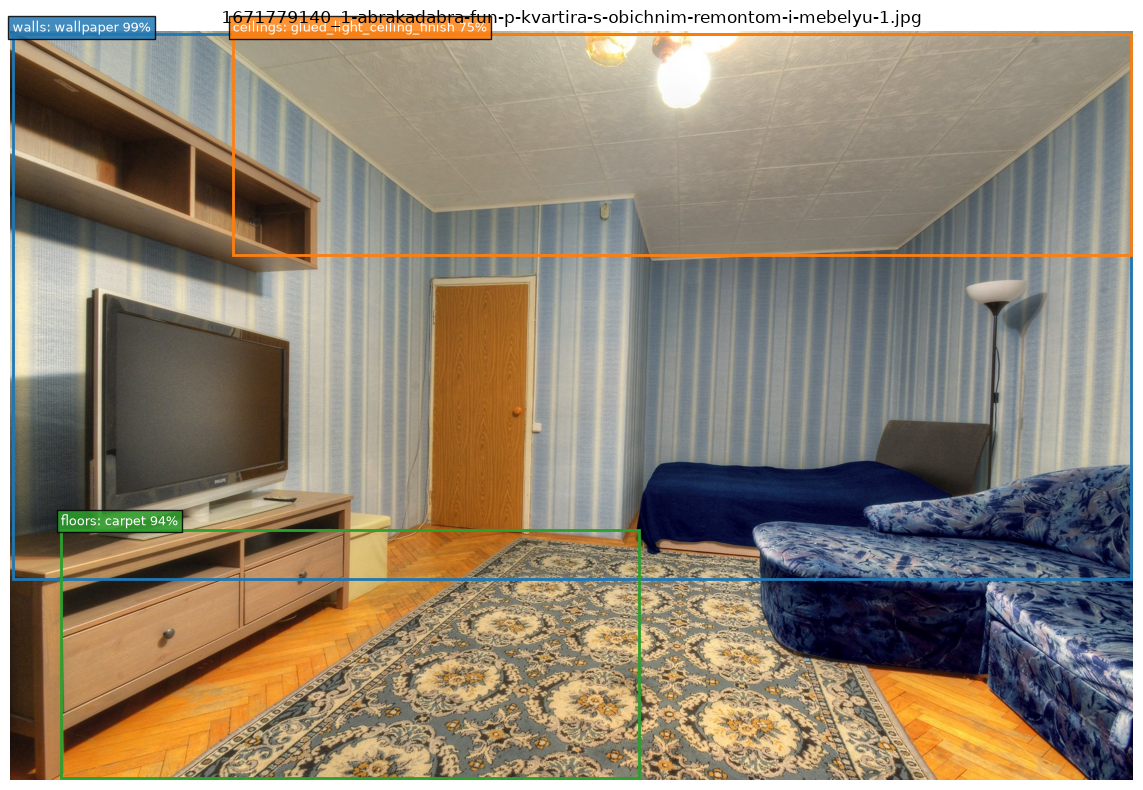

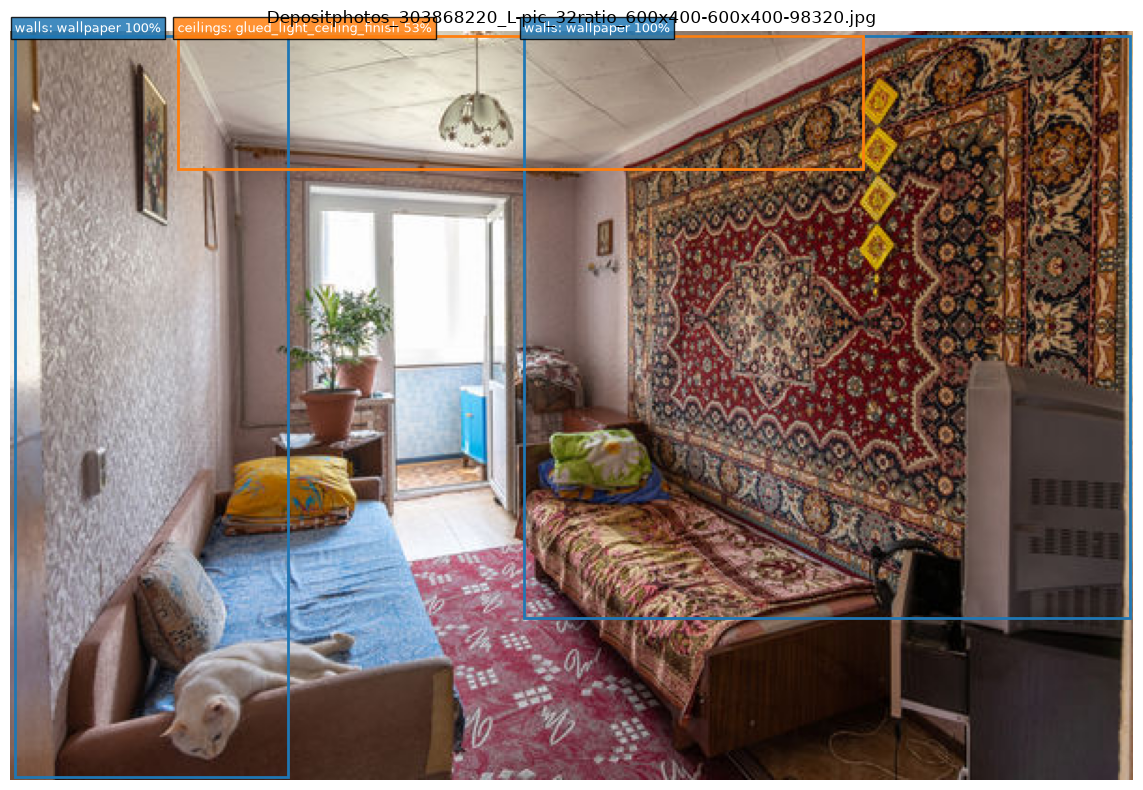

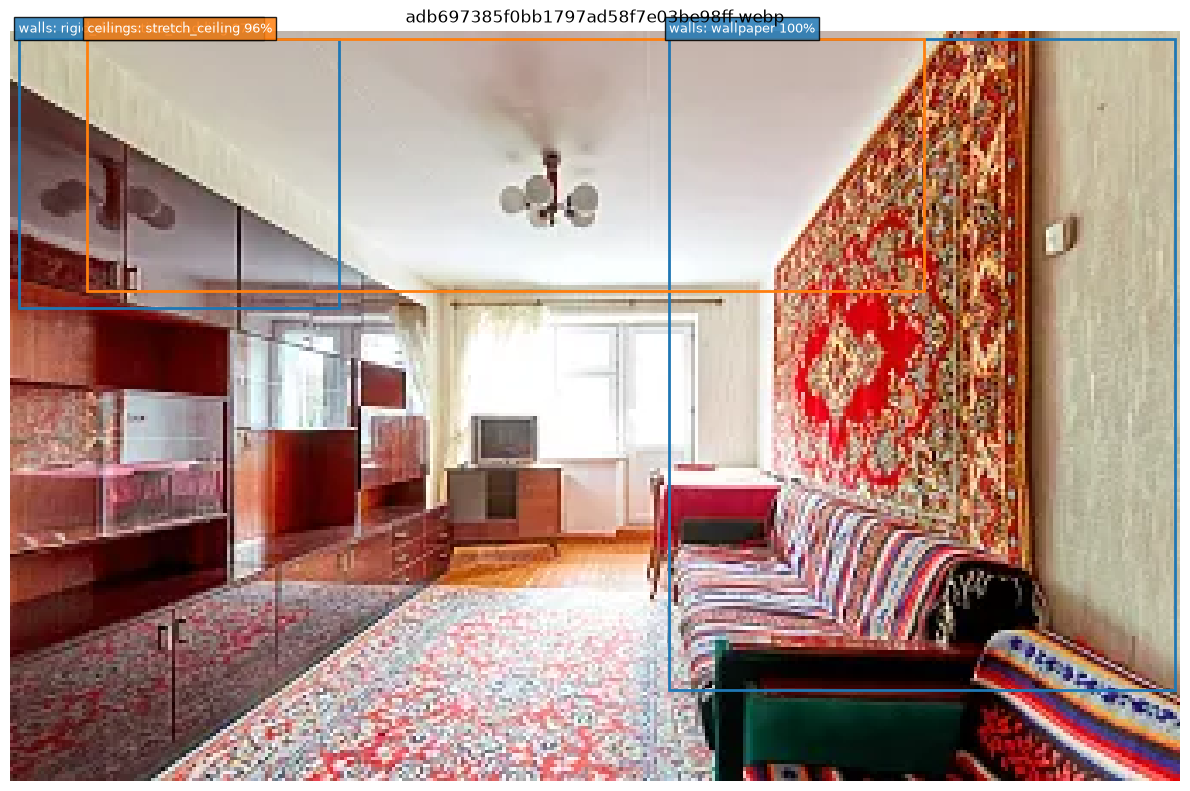

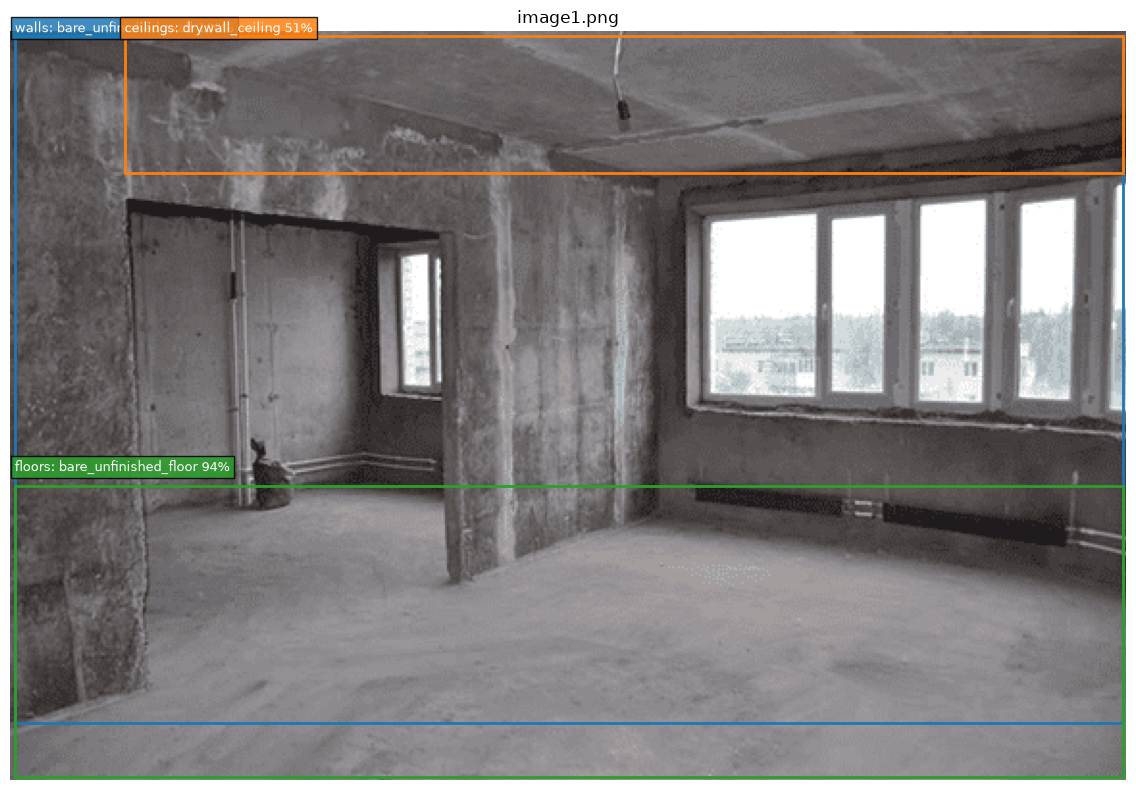

In [7]:
colors = {'walls':'tab:blue','floors':'tab:green','ceilings':'tab:orange'}
for image_result in detailed_results:
    with Image.open(image_result['path']) as source:
        image = ImageOps.exif_transpose(source).convert('RGB')
    fig, axis = plt.subplots(figsize=(12,8))
    axis.imshow(image)
    axis.set_title(image_result['image'])
    axis.axis('off')
    for surface, predictions in image_result['surfaces'].items():
        for prediction in predictions:
            box = prediction['bbox']
            rectangle = Rectangle(
                (box['x0'],box['y0']), box['x1']-box['x0'], box['y1']-box['y0'],
                fill=False, linewidth=2, edgecolor=colors[surface],
            )
            axis.add_patch(rectangle)
            axis.text(
                box['x0'], max(0,box['y0']-8),
                f"{surface}: {prediction['material']} {prediction['confidence']:.0%}",
                color='white', fontsize=9,
                bbox={'facecolor':colors[surface],'alpha':0.85,'pad':3},
            )
    plt.tight_layout()
    plt.show()
